In [1]:
import pandas as pd
df = pd.read_csv("economic_indicators_dataset_2010_2023.csv")
df.shape

(500, 7)

In [2]:
df.head()

,Date,Country,Inflation Rate (%),GDP Growth Rate (%),Unemployment Rate (%),Interest Rate (%),Stock Index Value
0,2010-01-31,Brazil,1.23,0.69,10.48,7.71,21748.85
1,2010-01-31,France,6.76,2.59,4.27,7.39,10039.56
2,2010-01-31,USA,7.46,4.84,2.64,6.39,13129.10
3,2010-02-28,Brazil,5.43,0.31,8.26,6.09,23304.58
4,2010-02-28,Canada,0.69,-0.52,11.92,-0.51,16413.03


In [3]:
df.tail()

,Date,Country,Inflation Rate (%),GDP Growth Rate (%),Unemployment Rate (%),Interest Rate (%),Stock Index Value
495,2023-08-31,Japan,5.71,-3.85,4.69,8.50,5968.07
496,2023-08-31,UK,4.82,8.95,10.91,8.87,21731.52
497,2023-09-30,USA,7.32,0.61,9.36,4.58,38924.38
498,2023-10-31,Germany,8.04,-2.23,2.89,8.04,39107.07
499,2023-11-30,Australia,9.23,6.16,6.78,9.49,21072.66


In [4]:
df.describe()

,Inflation Rate (%),GDP Growth Rate (%),Unemployment Rate (%),Interest Rate (%),Stock Index Value
count,500.00000,500.000000,500.000000,500.000000,500.000000
mean,5.08514,2.414780,6.906720,4.698180,20926.226540
std,2.95633,4.074762,2.982406,3.152877,11066.259233
min,0.00000,-5.000000,2.000000,-0.980000,1017.270000
25%,2.52500,-1.170000,4.257500,2.027500,11587.862500
50%,5.20500,2.580000,6.865000,4.975000,20996.210000
75%,7.71000,5.445000,9.502500,7.352500,30824.847500
max,9.99000,9.930000,11.970000,10.000000,39982.210000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   500 non-null    object 
 1   Country                500 non-null    object 
 2   Inflation Rate (%)     500 non-null    float64
 3   GDP Growth Rate (%)    500 non-null    float64
 4   Unemployment Rate (%)  500 non-null    float64
 5   Interest Rate (%)      500 non-null    float64
 6   Stock Index Value      500 non-null    float64
dtypes: float64(5), object(2)
memory usage: 27.5+ KB


In [6]:
print(df.duplicated().sum())

0


<Axes: xlabel='Date'>

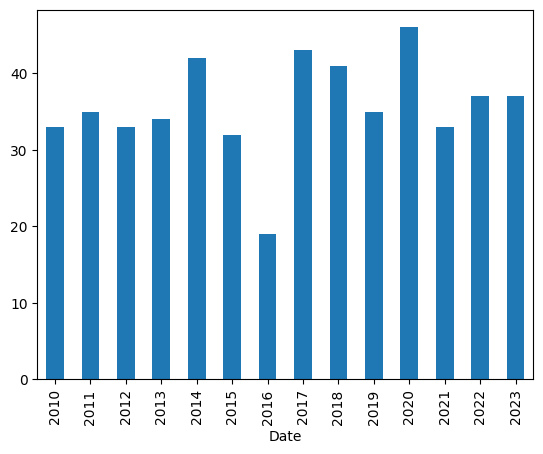

In [7]:
import matplotlib.pyplot as plt
Year = pd.to_datetime(df['Date']).dt.year
Year.value_counts().sort_index().plot(kind='bar')

<Axes: xlabel='Country'>

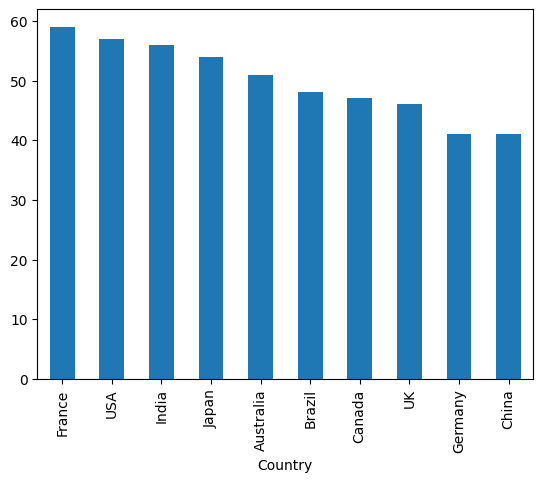

In [8]:
df['Country'].value_counts().plot(kind = 'bar')

In [ ]:
# variance of features by year
yearly_var = df.groupby(Year)[['Inflation Rate (%)', 'GDP Growth Rate (%)', 'Unemployment Rate (%)', 'Interest Rate (%)', 'Stock Index Value']].var()
yearly_var

,Inflation Rate (%),GDP Growth Rate (%),Unemployment Rate (%),Interest Rate (%),Stock Index Value
Date,,,,,
2010,9.623745,18.533246,9.389540,9.921256,1.062238e+08
2011,8.492122,17.841922,10.484953,9.050794,9.058108e+07
2012,9.047719,14.467306,9.336492,9.829848,1.260068e+08
2013,9.697154,18.084829,9.461118,10.393278,1.308680e+08
2014,8.222328,19.736320,8.378505,10.510679,1.091659e+08
2015,11.308547,16.543652,7.826371,11.073142,1.450278e+08
2016,10.071018,18.137278,9.555983,12.572454,1.261121e+08
2017,7.837182,18.645409,9.825023,8.417938,1.167979e+08
2018,8.479776,13.681707,8.707851,9.237131,9.487062e+07


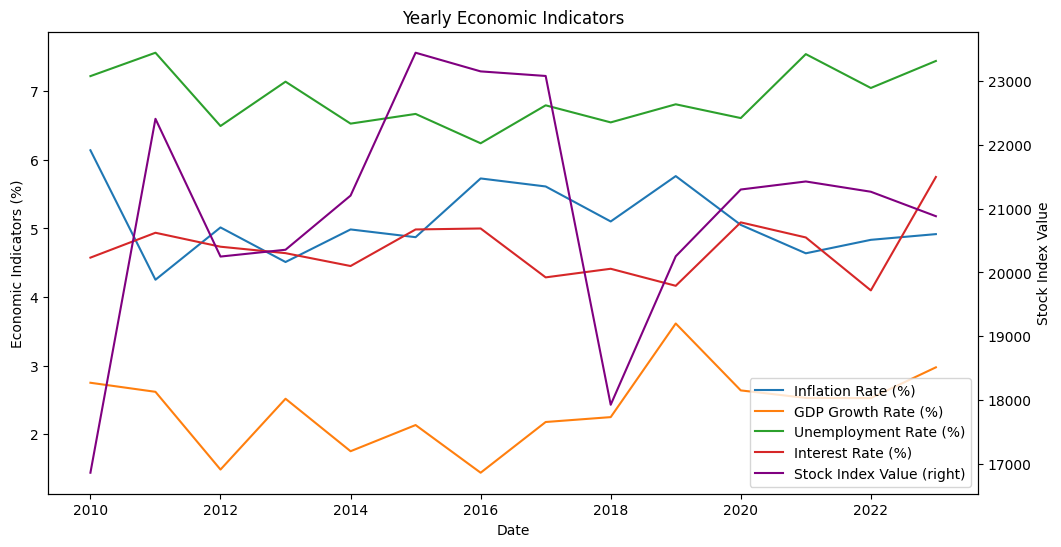

In [ ]:
# changes in features over the years
yearly_mean = df.groupby(Year)[['Inflation Rate (%)', 'GDP Growth Rate (%)', 'Unemployment Rate (%)', 'Interest Rate (%)', 'Stock Index Value']].mean()

# All features except the Stock Index Value are plotted on the left y-axis
ax = yearly_mean.plot(
    y=['Inflation Rate (%)', 'GDP Growth Rate (%)', 
       'Unemployment Rate (%)', 'Interest Rate (%)'],
    figsize=(12,6),
    title='Yearly Economic Indicators'
)

# The Stock Index Value is plotted on the right y-axis
yearly_mean.plot(
    y='Stock Index Value', 
    secondary_y=True, 
    ax=ax, 
    color='purple', 
    legend=True
)

ax.set_ylabel('Economic Indicators (%)')
ax.right_ax.set_ylabel('Stock Index Value')
plt.show()

In [11]:
df = df.drop('Date', axis=1)
df

,Country,Inflation Rate (%),GDP Growth Rate (%),Unemployment Rate (%),Interest Rate (%),Stock Index Value
0,Brazil,1.23,0.69,10.48,7.71,21748.85
1,France,6.76,2.59,4.27,7.39,10039.56
2,USA,7.46,4.84,2.64,6.39,13129.10
3,Brazil,5.43,0.31,8.26,6.09,23304.58
4,Canada,0.69,-0.52,11.92,-0.51,16413.03
...,...,...,...,...,...,...
495,Japan,5.71,-3.85,4.69,8.50,5968.07
496,UK,4.82,8.95,10.91,8.87,21731.52
497,USA,7.32,0.61,9.36,4.58,38924.38
498,Germany,8.04,-2.23,2.89,8.04,39107.07


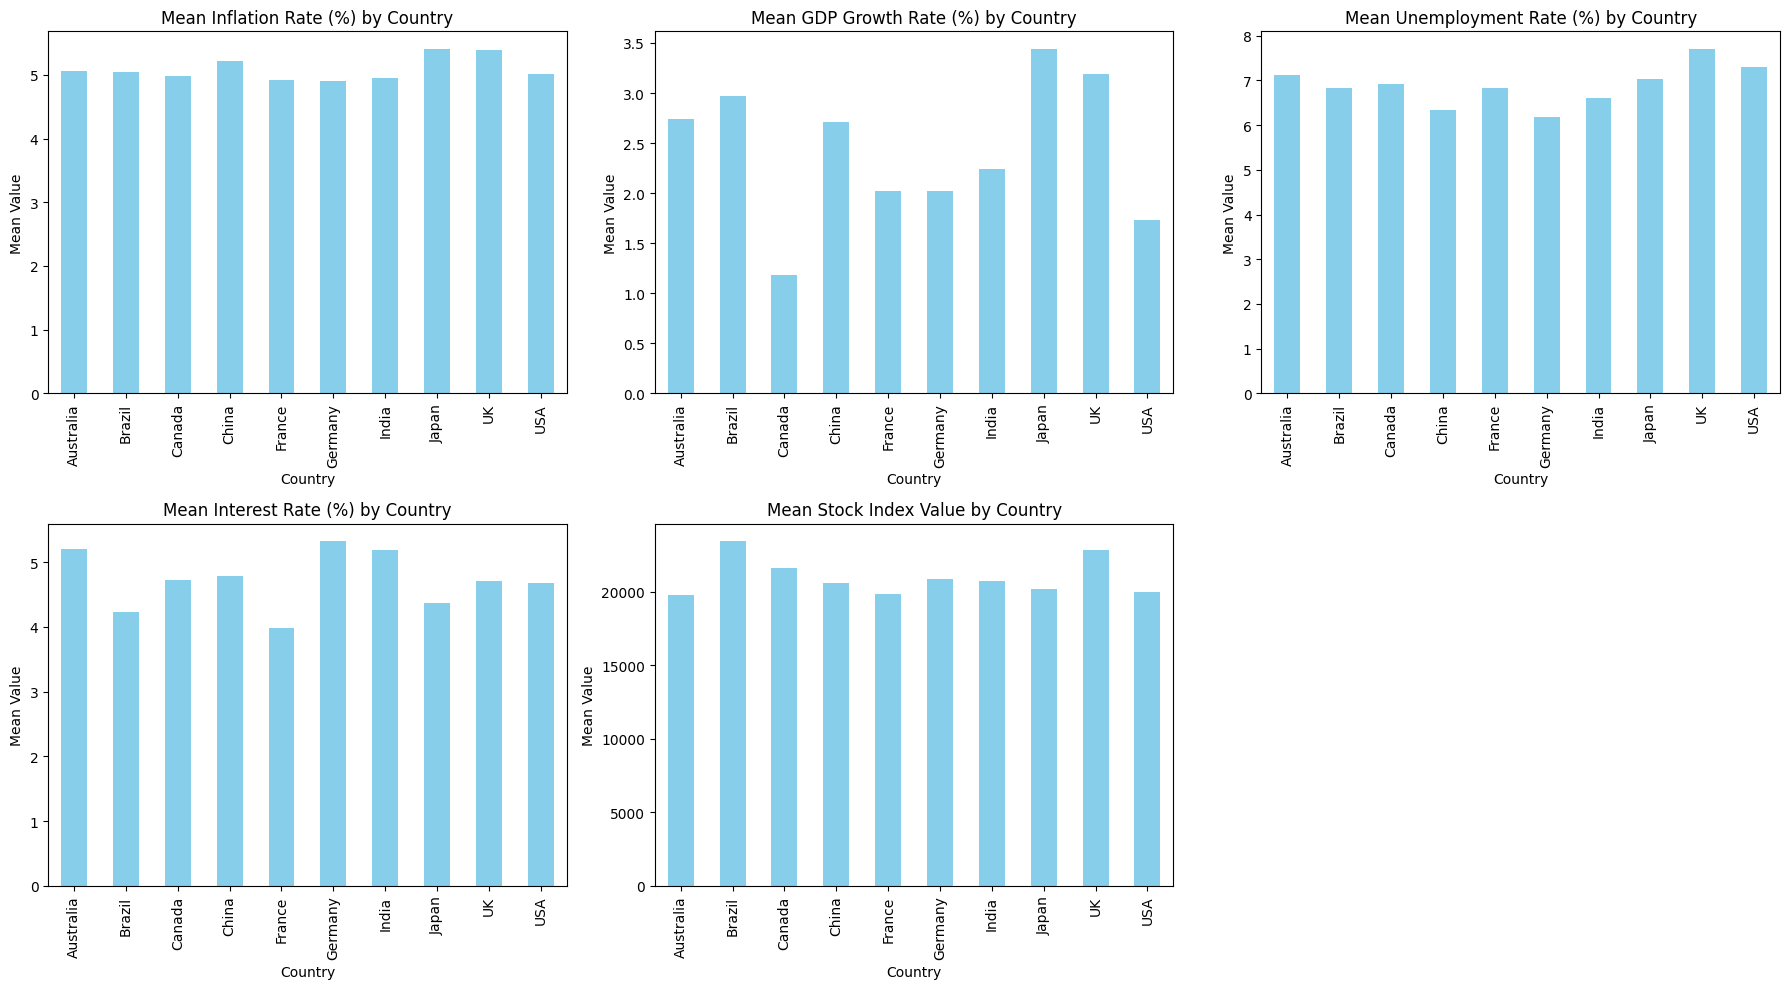

In [ ]:
# averages of each feature by country
num = ['Inflation Rate (%)', 'GDP Growth Rate (%)', 'Unemployment Rate (%)', 'Interest Rate (%)', 'Stock Index Value']
country_means = df.groupby('Country')[num].mean()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(num):
    country_means[feature].plot(kind='bar', ax=axes[i], color='skyblue')
    axes[i].set_title(f'Mean {feature} by Country')
    axes[i].set_xlabel('Country')
    axes[i].set_ylabel('Mean Value')
    axes[i].tick_params(axis='x', rotation=90)

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

In [13]:
df = pd.get_dummies(df, columns=['Country'], drop_first=True)
df

,Inflation Rate (%),GDP Growth Rate (%),Unemployment Rate (%),Interest Rate (%),Stock Index Value,Country_Brazil,Country_Canada,Country_China,Country_France,Country_Germany,Country_India,Country_Japan,Country_UK,Country_USA
0,1.23,0.69,10.48,7.71,21748.85,True,False,False,False,False,False,False,False,False
1,6.76,2.59,4.27,7.39,10039.56,False,False,False,True,False,False,False,False,False
2,7.46,4.84,2.64,6.39,13129.10,False,False,False,False,False,False,False,False,True
3,5.43,0.31,8.26,6.09,23304.58,True,False,False,False,False,False,False,False,False
4,0.69,-0.52,11.92,-0.51,16413.03,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,5.71,-3.85,4.69,8.50,5968.07,False,False,False,False,False,False,True,False,False
496,4.82,8.95,10.91,8.87,21731.52,False,False,False,False,False,False,False,True,False
497,7.32,0.61,9.36,4.58,38924.38,False,False,False,False,False,False,False,False,True
498,8.04,-2.23,2.89,8.04,39107.07,False,False,False,False,True,False,False,False,False


<Axes: >

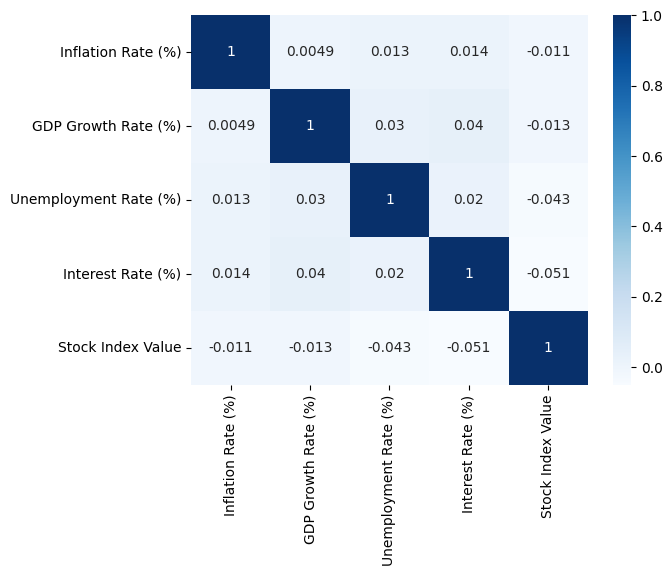

In [14]:
import seaborn as sns
sns.heatmap(df[num].corr(),annot=True,cmap="Blues")

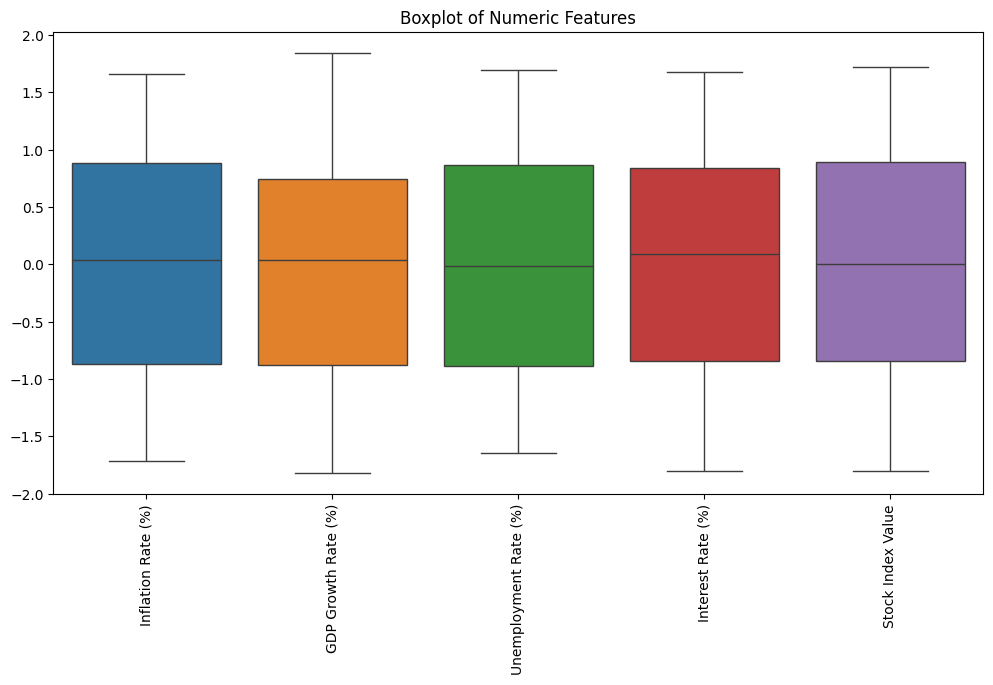

In [ ]:
data = df[num]

# To display them together, standardization was applied
data = (data - data.mean()) / (data.std())

plt.figure(figsize=(12, 6))
sns.boxplot(data=data)
plt.title('Boxplot of Numeric Features')
plt.xticks(rotation=90)
plt.show()

In [ ]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

X = df.drop('Inflation Rate (%)', axis=1)
y = df['Inflation Rate (%)']
names = ['GDP Growth Rate (%)', 'Unemployment Rate (%)', 'Interest Rate (%)', 'Stock Index Value']

# Time series was split into intervals of two years
tscv = TimeSeriesSplit(n_splits=7)

# A preprocessor that performs standardization only on columns included in the names list
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), names)
    ],
    remainder='passthrough'
)

# Pipeline (preprocessor + model)
pipe_rf = Pipeline([
    ('preprocess', preprocessor),
    ('rf', RandomForestRegressor(random_state=42))
])

# Hyperparameter grid setup
param_grid = {
    'rf__n_estimators': [50, 100],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5]
}

# GridSearch
grid = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error' # MSE 최소화
)
grid.fit(X, y)

# Evaluation
best_model = grid.best_estimator_
y_pred = best_model.predict(X)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print("Random Forest Results:")
print(f"Best Params: {grid.best_params_}")
print(f"Best Score (MSE): {-grid.best_score_:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

Random Forest Results:
Best Params: {'rf__max_depth': 10, 'rf__min_samples_split': 2, 'rf__n_estimators': 50}
Best Score (MSE): 9.3272
RMSE: 1.8776
R²: 0.5958
